# Cook County — Property Tax Equity Analysis

Runs the full property tax equity analysis for Cook County using CCAO open data.
The AVM uses XGBoost/LightGBM with spatial features; assessment equity uses OLS at the tract level; LVT simulation uses per-PIN composite rates from the Cook County tax code.

In [1]:
import sys, os
from pathlib import Path
_here = Path(os.path.abspath(''))
sys.path.insert(0, str(_here if (_here / 'src').exists() else _here.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from src.config import get_city_config, RAW_DIR, PROCESSED_DIR, FIGURES_DIR, CLUSTER_FEATURES, RANDOM_STATE
from src.data_utils import add_groups, load_cook_tax_rates
from src.model_utils import (
    prep_data, fit_regressors, predict_all,
    fit_classifiers,
)
from src.tax_utils import compute_lvt, aggregate_lvt_to_tracts, gini_coefficient
from src.viz_utils import (
    plot_feature_importance, plot_actual_vs_predicted,
    plot_assessment_ratio_by_group, plot_intersectional_heatmap,
    plot_lvt_benefit_by_group, plot_effective_rate_comparison,
    plot_cluster_heatmap, plot_cluster_map,
    plot_roc_curves, plot_permutation_importance,
)

CITY  = 'cook'   # ← change to 'nyc' or 'philly' for other cities
cfg   = get_city_config(CITY)
FILES = cfg['files']
PID   = cfg['parcel_id']
LABEL = cfg['label']

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print(f'City: {LABEL}')

City: Cook County, IL


## Task 1: Property Valuation Model

Train a set of regressors (Ridge, Random Forest, Gradient Boosting, XGBoost) on
log-transformed sale prices to estimate market value.  The best model (XGBoost) is
then used to predict market values for all residential parcels so that assessment
ratios (assessed / predicted) can be computed in Task 2.


In [2]:
training = pd.read_parquet(PROCESSED_DIR / FILES['training'])
residential = pd.read_parquet(PROCESSED_DIR / FILES['residential'])

if cfg['year_built_col']:
    for df in [training, residential]:
        df['age'] = (2023 - df[cfg['year_built_col']].clip(1800, 2023)).clip(0, 150)

print(f'{len(training):,} training, {len(residential):,} residential')

X_train, X_test, y_train_log, y_test_log = prep_data(
    training, cfg['numeric_features'], cfg['categorical_features']
)
trained_models, val_results = fit_regressors(
    X_train, X_test, y_train_log, y_test_log,
    cfg['numeric_features'], cfg['categorical_features'],
)
print('\nModel comparison:')
display(val_results.round(4))


127,549 training, 1,635,253 residential
  Training Linear Regression...
  Training Random Forest...
  Training XGBoost...
  Training LightGBM...

Model comparison:


,Model,R²,RMSE ($),MAE ($),MdAPE (%)
0,Linear Regression,0.6557,"172,455.1589","101,243.0661",19.4508
1,Random Forest,0.7870,"135,638.1810","82,670.1881",15.9283
2,XGBoost,0.8120,"127,459.2871","78,613.9608",15.3958
3,LightGBM,0.8172,"125,658.8681","77,774.4591",15.1522


Best model: LightGBM  (R² = 0.8172)
Saved 1,635,253 rows → cook_residential_with_predictions.parquet


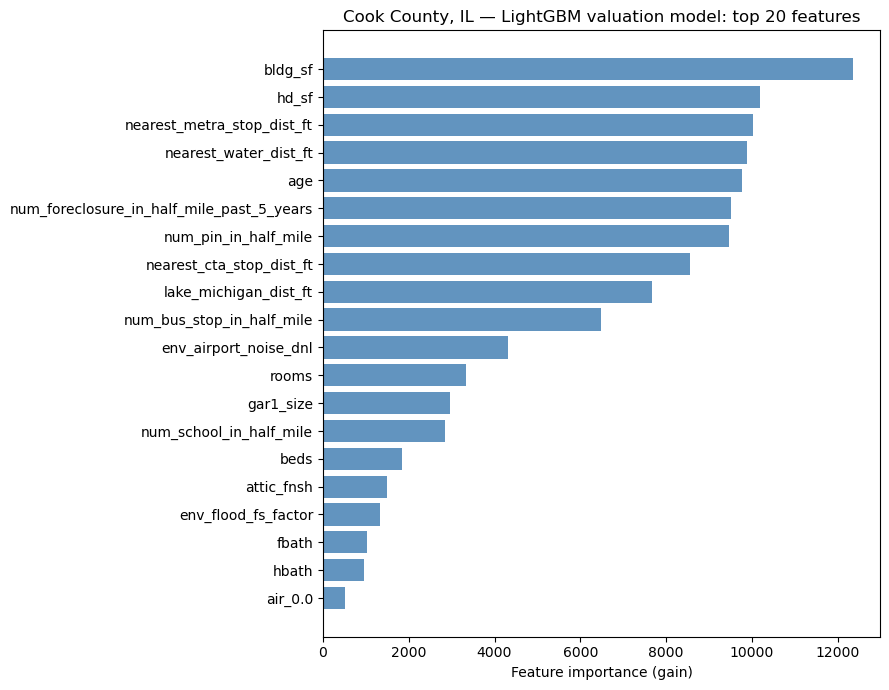

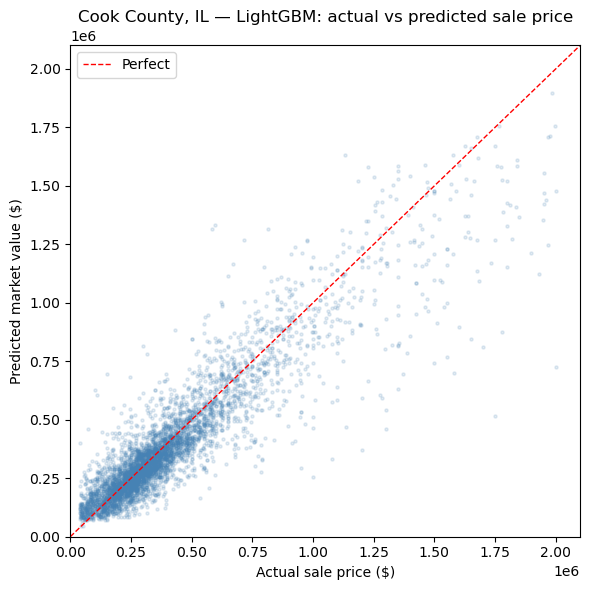

In [3]:
best_model_name = val_results.loc[val_results['R²'].idxmax(), 'Model']
print(f'Best model: {best_model_name}  (R² = {val_results["R²"].max():.4f})')

residential['predicted_market_value'] = predict_all(
    trained_models[best_model_name], residential,
    cfg['numeric_features'], cfg['categorical_features'],
)
residential['assessment_ratio'] = (
    residential['market_value_total'] / residential['predicted_market_value']
).clip(cfg['fair_ratio'] * 0.2, cfg['fair_ratio'] * 5.0)
if 'land_ratio' not in residential.columns:
    residential['land_ratio'] = (
        residential['market_value_land'] / residential['market_value_total'].replace(0, np.nan)
    )
residential = add_groups(residential)
residential.to_parquet(PROCESSED_DIR / FILES['residential_pred'], index=False)
print(f'Saved {len(residential):,} rows → {FILES["residential_pred"]}')

y_test_dollars = np.expm1(y_test_log.values)
y_pred_dollars = np.expm1(trained_models[best_model_name].predict(X_test))

plot_feature_importance(
    trained_models[best_model_name],
    title=f'{LABEL} — {best_model_name} valuation model: top 20 features',
    n=20, save_path=FIGURES_DIR / f'{CITY}_feature_importance.png',
)
plt.show()

plot_actual_vs_predicted(
    y_test_dollars, y_pred_dollars,
    title=f'{LABEL} — {best_model_name}: actual vs predicted sale price',
    save_path=FIGURES_DIR / f'{CITY}_predicted_vs_actual.png',
)
plt.show()

## Task 2: Assessment Bias Detection

Aggregate parcel-level predictions to Census-tract level and run an OLS regression:

```
median_assessment_ratio ~ log_income + pct_black + pct_hispanic
                        + log_predicted_value + median_land_ratio
                        + pct_owner_occupied
```

Significant positive coefficients on `pct_black` / `pct_hispanic` indicate that
minority-majority tracts bear a disproportionate assessment burden (over-assessment
relative to market value).


In [4]:
analysis = residential[
    residential['assessment_ratio'].notna() &
    residential['median_household_income'].notna() &
    residential['pct_black'].notna() &
    (residential['predicted_market_value'] > 0)
].copy()

tract_stats = analysis.groupby('census_tract_geoid').agg(
    median_ratio=('assessment_ratio', 'median'),
    median_predicted_value=('predicted_market_value', 'median'),
    median_land_ratio=('land_ratio', 'median'),
    n_parcels=(PID, 'count'),
    median_household_income=('median_household_income', 'first'),
    pct_black=('pct_black', 'first'),
    pct_hispanic=('pct_hispanic', 'first'),
    pct_white=('pct_white', 'first'),
    pct_owner_occupied=('pct_owner_occupied', 'first'),
).reset_index()
tract_stats = tract_stats[tract_stats['n_parcels'] >= 20].copy()

tract_stats['log_income'] = np.log(tract_stats['median_household_income'])
tract_stats['log_predicted_value'] = np.log(tract_stats['median_predicted_value'].clip(lower=1000))
tract_stats['majority_black'] = (tract_stats['pct_black'] > 50).astype(int)
tract_stats['majority_hispanic'] = (tract_stats['pct_hispanic'] > 50).astype(int)
tract_stats['majority_white'] = (tract_stats['pct_white'] > 50).astype(int)
tract_stats['majority_group'] = np.where(
    tract_stats['pct_black'] > 50, 'Majority Black',
    np.where(tract_stats['pct_hispanic'] > 50, 'Majority Hispanic',
    np.where(tract_stats['pct_white'] > 50, 'Majority White', 'Mixed')),
)
tract_stats['income_quintile'] = pd.qcut(
    tract_stats['median_household_income'],
    q=5, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'],
)

model_bias = smf.ols(
    'median_ratio ~ log_income + pct_black + pct_hispanic + '
    'log_predicted_value + median_land_ratio + pct_owner_occupied',
    data=tract_stats,
).fit()

print(f'Tracts in analysis: {len(tract_stats):,}')
print(model_bias.summary().tables[1])
print(f'\nR²: {model_bias.rsquared:.4f}  |  N: {int(model_bias.nobs)}')
print('\nMedian assessment ratio by racial group:')
print(tract_stats.groupby('majority_group')['median_ratio'].median().round(3).to_string())

tract_stats.to_parquet(PROCESSED_DIR / FILES['tract_analysis'], index=False)


Tracts in analysis: 1,270
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.3705      0.221      1.676      0.094      -0.063       0.804
log_income              0.1096      0.018      5.963      0.000       0.074       0.146
pct_black              -0.0002      0.000     -0.874      0.382      -0.001       0.000
pct_hispanic            0.0013      0.000      4.756      0.000       0.001       0.002
log_predicted_value    -0.0853      0.017     -5.022      0.000      -0.119      -0.052
median_land_ratio      -0.0811      0.048     -1.672      0.095      -0.176       0.014
pct_owner_occupied      0.0032      0.000      9.728      0.000       0.003       0.004

R²: 0.3386  |  N: 1270

Median assessment ratio by racial group:
majority_group
Majority Black      0.6300
Majority Hispanic   0.7760
Majority White      0.8160
Mixed               

In [5]:
from src.model_utils import compute_iaao_metrics

test_sales = residential[residential['sale_price'].notna()].copy()

# Cook County residential assessment level = 10%; divide final_tot by 0.10 for implied MV
iaao = compute_iaao_metrics(
    sale_prices=test_sales['sale_price'].values,
    assessed_values=test_sales['final_tot'].values,
    assessment_level=0.10,
)

print(f'IAAO ({iaao["n"]:,} sales): median ratio {iaao["median_ratio"]:.3f}')
print(f'  COD {iaao["cod"]:.1f}% (standard 5-15: {"ok" if iaao["cod_pass"] else "fail"}),  '
      f'PRD {iaao["prd"]:.3f} (standard 0.98-1.03: {"ok" if iaao["prd_pass"] else "fail"}),  '
      f'PRB {iaao["prb"]:.3f} (standard -0.05-0.05: {"ok" if iaao["prb_pass"] else "fail"})')
if not iaao['prb_pass']:
    direction = 'regressive' if iaao['prb'] < 0 else 'progressive'
    print(f'  PRB direction: {direction}')


IAAO (196,029 sales): median ratio 0.884
  COD 28.1% (standard 5-15: fail),  PRD 1.093 (standard 0.98-1.03: fail),  PRB 0.015 (standard -0.05-0.05: ok)


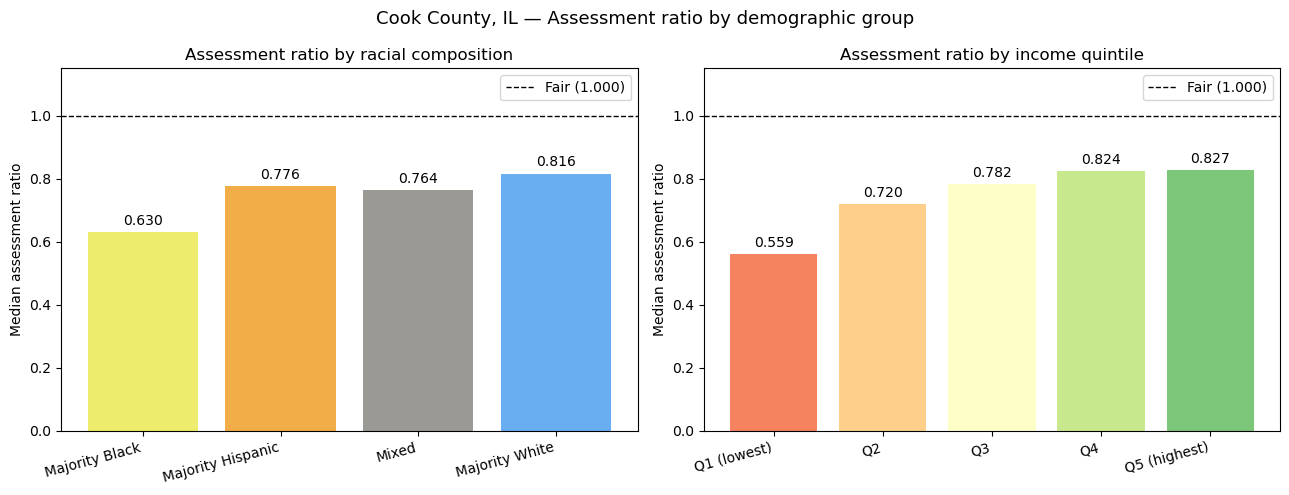

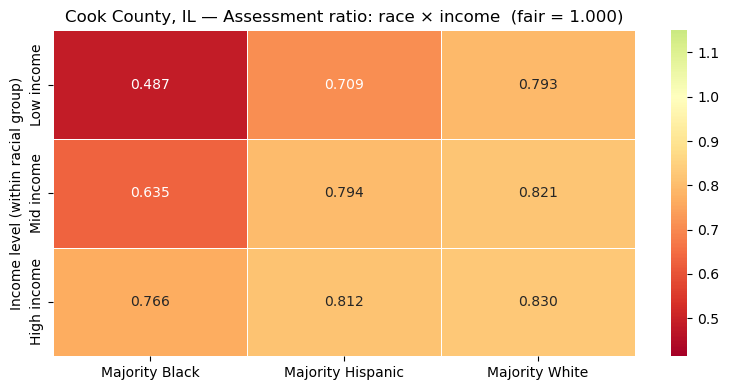

In [6]:
plot_assessment_ratio_by_group(
    tract_stats, city_label=LABEL, fair_ratio=cfg['fair_ratio'],
    save_path=FIGURES_DIR / f'{CITY}_assessment_ratio_by_group.png',
)
plt.show()

groups = []
for race_label, race_col in [
    ('Majority Black',    'majority_black'),
    ('Majority Hispanic', 'majority_hispanic'),
    ('Majority White',    'majority_white'),
]:
    subset = tract_stats[tract_stats[race_col] == 1].copy()
    if len(subset) < 10:
        continue
    subset['income_tercile'] = pd.qcut(
        subset['median_household_income'],
        q=3, labels=['Low income', 'Mid income', 'High income'],
        duplicates='drop',
    )
    for tercile in ['Low income', 'Mid income', 'High income']:
        t = subset[subset['income_tercile'] == tercile]
        if len(t) > 0:
            groups.append({'Race': race_label, 'Income': tercile,
                           'Median ratio': t['median_ratio'].median(), 'N': len(t)})

intersect = pd.DataFrame(groups)
plot_intersectional_heatmap(
    intersect, city_label=LABEL, fair_ratio=cfg['fair_ratio'],
    save_path=FIGURES_DIR / f'{CITY}_intersectional_heatmap.png',
)
plt.show()

## Task 3: Revenue-Neutral LVT Simulation

Replace the current property tax (levied on land + improvements) with a
land-value tax (LVT) levied solely on land value, keeping total revenue constant.

The simulation:
1. Computes current estimated tax for every parcel using the statutory composite rate.
2. Scales the pure land-value tax so that city-wide revenue is unchanged.
3. Records `tax_change` (LVT minus current) and `lvt_benefits` (True if parcel pays
   less under LVT) for every residential parcel.
4. Computes Gini coefficients for effective tax rates under both regimes.


In [7]:
all_parcels = pd.read_parquet(PROCESSED_DIR / FILES['all_parcels'])

# rate fallback hierarchy in notes.md
_rates = load_cook_tax_rates(RAW_DIR, PROCESSED_DIR)
if _rates is not None:
    all_parcels = all_parcels.merge(_rates, on=PID, how='left')
    all_parcels['composite_rate'] = all_parcels['composite_rate'].fillna(cfg['composite_rate'])
    _rate_arg = 'composite_rate'
    print(f'Using per-parcel rates: median {all_parcels["composite_rate"].median()*100:.2f}%, '
          f'range {all_parcels["composite_rate"].min()*100:.1f}%–{all_parcels["composite_rate"].max()*100:.1f}%')
else:
    _rate_arg = cfg['composite_rate']
    print(f'Using flat composite rate: {cfg["composite_rate"]*100:.1f}%')

taxable, lvt_mult = compute_lvt(
    all_parcels,
    state_equalizer    = cfg['state_equalizer'],
    composite_rate     = _rate_arg,
    tax_base_total_col = cfg['tax_base_total'],
    tax_base_land_col  = cfg['tax_base_land'],
)

lvt_cols = [PID, 'current_tax_est', 'lvt_tax_est', 'tax_change', 'tax_change_pct', 'lvt_benefits']
res_lvt = residential.merge(taxable[lvt_cols], on=PID, how='inner').drop_duplicates(subset=PID)
res_lvt = add_groups(res_lvt)

print(f'Residential parcels with LVT: {len(res_lvt):,}')
print(f'Overall: {res_lvt["lvt_benefits"].mean()*100:.1f}% pay LESS under LVT')

print('\nLVT impact by racial group:')
for g in ['Majority Black', 'Majority Hispanic', 'Mixed', 'Majority White']:
    sub = res_lvt[res_lvt['majority_group'] == g]
    if len(sub):
        print(f'  {g}: {sub["lvt_benefits"].mean()*100:.1f}%  (median change ${sub["tax_change"].median():,.0f})')

valid = res_lvt[
    (res_lvt['predicted_market_value'] > 0) &
    (res_lvt['current_tax_est'] > 0) & (res_lvt['lvt_tax_est'] > 0)
].copy()
valid['eff_current'] = valid['current_tax_est'] / valid['predicted_market_value']
valid['eff_lvt']     = valid['lvt_tax_est']     / valid['predicted_market_value']
print(f'\nGini (effective rate):  current = {gini_coefficient(valid["eff_current"].values):.4f}'
      f',  LVT = {gini_coefficient(valid["eff_lvt"].values):.4f}')

res_lvt.to_parquet(PROCESSED_DIR / FILES['residential_lvt'], index=False)

  Tax-code rates (pin_tax_codes): 1,864,012/1,864,035 PINs (100.0%), median 7.52%
Using per-parcel rates: median 7.52%, range 1.7%–32.1%
LVT multiplier:       4.4021x
Revenue neutral check: $+0
Residential parcels with LVT: 1,605,925
Overall: 61.3% pay LESS under LVT

LVT impact by racial group:
  Majority Black: 46.6%  (median change $155)
  Majority Hispanic: 57.8%  (median change $-327)
  Mixed: 69.3%  (median change $-1,149)
  Majority White: 64.2%  (median change $-871)

Gini (effective rate):  current = 0.3957,  LVT = 0.4332


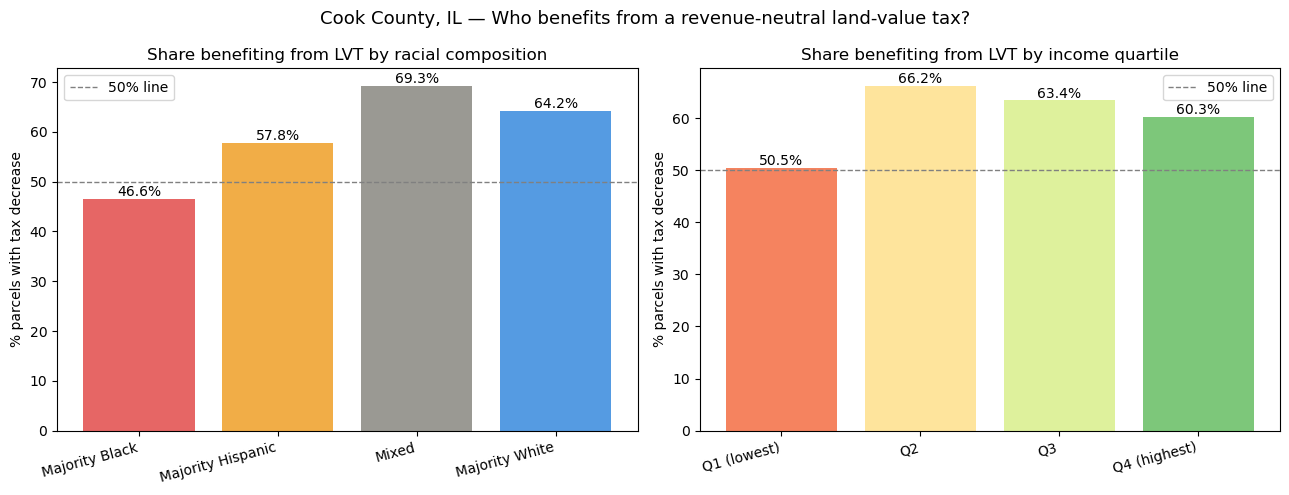

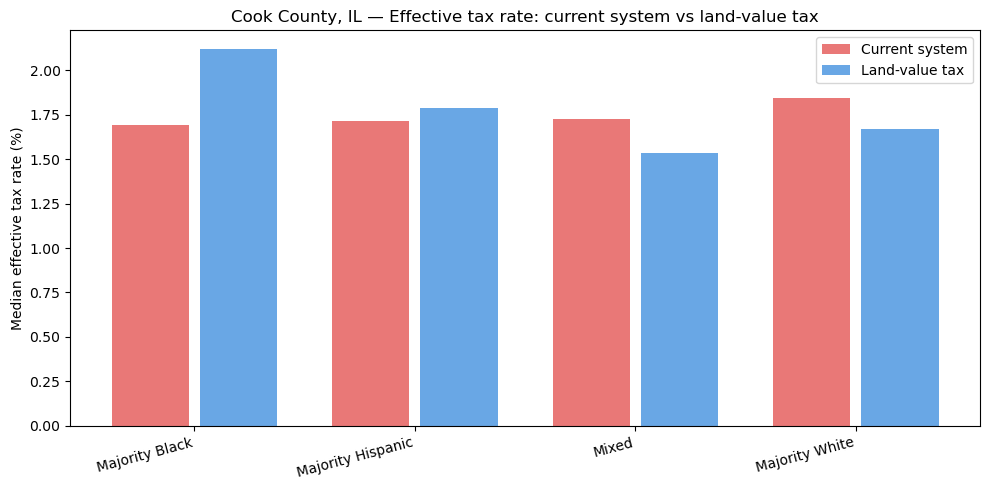

In [8]:
plot_lvt_benefit_by_group(
    res_lvt, city_label=LABEL,
    save_path=FIGURES_DIR / f'{CITY}_lvt_benefit_by_group.png',
)
plt.show()

plot_effective_rate_comparison(
    res_lvt, city_label=LABEL,
    save_path=FIGURES_DIR / f'{CITY}_effective_rate_comparison.png',
)
plt.show()


## Task 4: Neighborhood Clustering

Cluster Census tracts using PCA (retaining 90 % of variance) followed by a
Gaussian Mixture Model (GMM) with the number of components chosen by minimising
the Bayesian Information Criterion (BIC) over k = 2 … 8.

Features used span valuation, demographics, assessment equity, and LVT impact
(see `CLUSTER_FEATURES` in `src/config.py`).


In [9]:
tract_stats = pd.read_parquet(PROCESSED_DIR / FILES['tract_analysis'])
res_lvt     = pd.read_parquet(PROCESSED_DIR / FILES['residential_lvt'])

lvt_tract = aggregate_lvt_to_tracts(res_lvt)
tracts    = tract_stats.merge(lvt_tract, on='census_tract_geoid', how='inner')

cluster_df = tracts[CLUSTER_FEATURES + ['census_tract_geoid']].dropna().copy()
X_scaled   = StandardScaler().fit_transform(cluster_df[CLUSTER_FEATURES])

pca     = PCA(random_state=RANDOM_STATE)
cum_var = np.cumsum(pca.fit(X_scaled).explained_variance_ratio_)
n_comp  = int(np.argmax(cum_var >= 0.90)) + 1
X_pca   = PCA(n_components=n_comp, random_state=RANDOM_STATE).fit_transform(X_scaled)
print(f'PCA: {n_comp} components → {cum_var[n_comp-1]*100:.1f}% variance')

bic_scores = []
for k in range(2, 9):
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=5, random_state=RANDOM_STATE)
    bic_scores.append(gmm.fit(X_pca).bic(X_pca))
best_k = 2 + int(np.argmin(bic_scores))
print(f'Best k by BIC: {best_k}')

final_gmm             = GaussianMixture(n_components=best_k, covariance_type='full',
                                         n_init=10, random_state=RANDOM_STATE)
cluster_df['cluster'] = final_gmm.fit_predict(X_pca)
print(f'Silhouette score: {silhouette_score(X_pca, cluster_df["cluster"]):.3f}')

profile_features = [
    'median_household_income', 'pct_black', 'pct_hispanic', 'pct_owner_occupied',
    'median_predicted_value', 'median_ratio', 'median_land_ratio',
    'median_tax_change_pct', 'pct_lvt_benefit',
]
profile_summary          = cluster_df.groupby('cluster')[profile_features].median()
profile_summary['n_tracts'] = cluster_df.groupby('cluster').size()
print('\nCluster profiles:')
display(profile_summary.T.round(2))

cluster_df.to_parquet(PROCESSED_DIR / FILES['tracts_clusters'], index=False)


PCA: 5 components → 94.8% variance
Best k by BIC: 8
Silhouette score: 0.144

Cluster profiles:


cluster,0,1,2,3,4,5,6,7
median_household_income,"131,389.5000","79,750.0000","45,458.0000","74,554.0000","41,008.0000","59,332.0000","76,601.5000","117,073.0000"
pct_black,3.4700,4.1400,93.7400,1.8900,75.4200,56.9800,9.6800,2.6700
pct_hispanic,9.2300,41.0400,1.6800,67.1100,17.3000,28.3200,13.3600,10.6100
pct_owner_occupied,43.8800,50.0300,36.4500,69.8600,44.1100,61.9200,45.1900,85.6900
median_predicted_value,"914,916.8400","427,271.0700","196,826.7400","271,529.5900","147,597.0900","202,849.5600","506,405.8700","411,578.9800"
median_ratio,0.5600,0.8000,0.6300,0.8500,0.4400,0.8300,0.4400,0.8700
median_land_ratio,0.2300,0.2700,0.2800,0.1900,0.4500,0.2000,0.1300,0.2100
median_tax_change_pct,2.3500,16.8700,24.5800,-17.4600,96.0700,-13.2700,-42.0000,-8.1600
pct_lvt_benefit,48.8900,30.0900,30.8900,77.1700,10.7600,69.0600,81.0800,61.7000
n_tracts,142.0000,226.0000,161.0000,157.0000,74.0000,130.0000,170.0000,210.0000


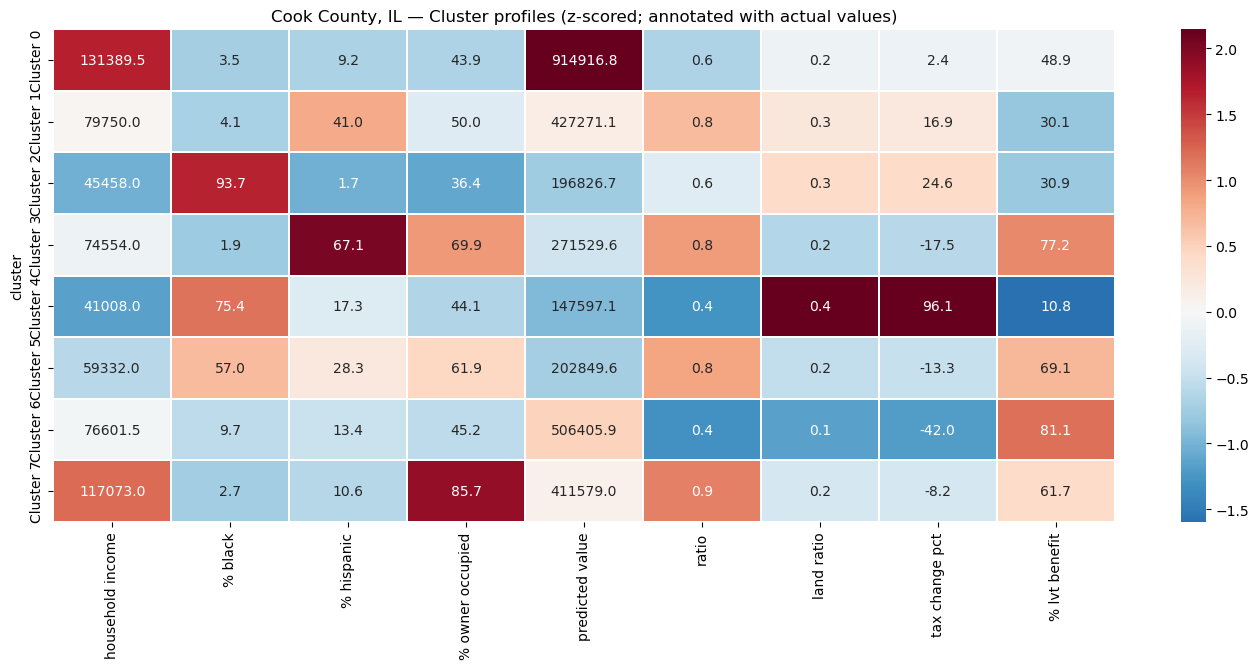

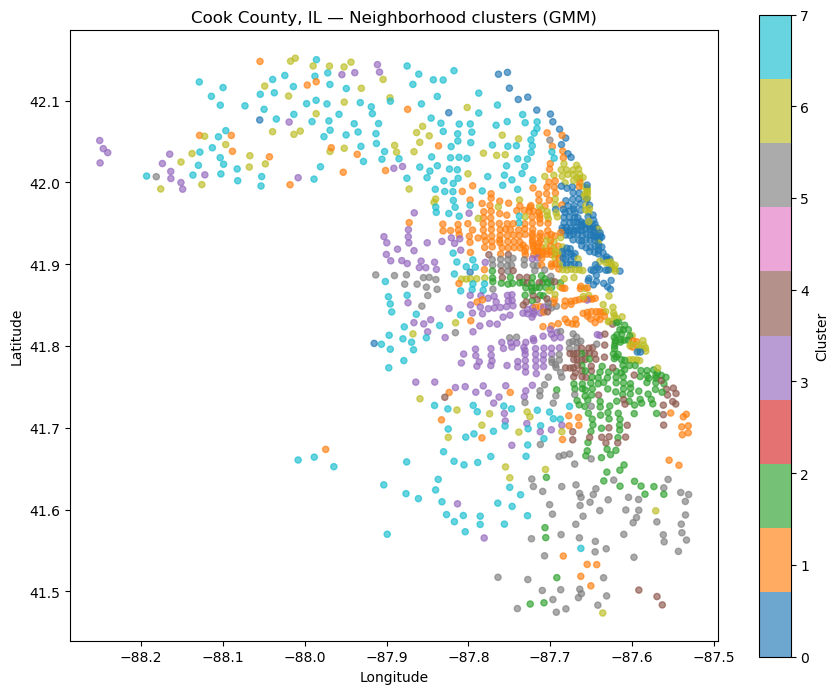

In [10]:
plot_cluster_heatmap(
    profile_summary, profile_features, n_clusters=best_k,
    city_label=LABEL, save_path=FIGURES_DIR / f'{CITY}_cluster_heatmap.png',
)
plt.show()

if cfg['lat'] and cfg['lon']:
    tract_coords = res_lvt.groupby('census_tract_geoid').agg(
        lat=(cfg['lat'], 'median'), lon=(cfg['lon'], 'median')
    ).reset_index()
    map_df = (
        cluster_df[['census_tract_geoid', 'cluster']]
        .merge(tract_coords, on='census_tract_geoid', how='inner')
        .dropna(subset=['lat', 'lon'])
    )
    plot_cluster_map(
        map_df, city_label=LABEL,
        save_path=FIGURES_DIR / f'{CITY}_cluster_map.png',
    )
    plt.show()
else:
    print('No coordinate data available — geographic map skipped.')


## Task 5: LVT Beneficiary Classification

Train three classifiers (Logistic Regression, Random Forest, Gradient Boosting) to
predict whether a residential parcel benefits under the LVT shift (i.e., pays less
tax), using parcel characteristics and tract-level demographics as features.

Performance is evaluated via AUC-ROC; permutation importance identifies the most
predictive features.


In [11]:
res_lvt = pd.read_parquet(PROCESSED_DIR / FILES['residential_lvt'])

_LEAKY_FEATURES = {'market_value_total', 'market_value_land'}

clf_features = list(dict.fromkeys([
    f for f in
    ['assessment_ratio']
    + cfg['numeric_features']
    + ['median_household_income', 'pct_black', 'pct_hispanic', 'pct_owner_occupied']
    if f in res_lvt.columns and f not in _LEAKY_FEATURES
]))

model_df = res_lvt[clf_features + ['lvt_benefits']].copy()
for col in clf_features:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')
model_df = model_df.dropna()
model_df['lvt_benefits'] = model_df['lvt_benefits'].astype(int)

sample_df = model_df.sample(n=min(100_000, len(model_df)), random_state=RANDOM_STATE)
X = sample_df[clf_features].values
y = sample_df['lvt_benefits'].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
scaler_c = StandardScaler()
X_train_scaled = scaler_c.fit_transform(X_train_c)
X_test_scaled = scaler_c.transform(X_test_c)

print(f'{len(clf_features)} features, {len(X_train_c):,} train / {len(X_test_c):,} test, '
      f'benefit rate {y.mean()*100:.1f}%')

clf_models, clf_results = fit_classifiers(
    X_train_scaled, X_test_scaled, y_train_c, y_test_c
)
print('\nClassifier comparison:')
display(clf_results.round(4))


25 features, 80,000 train / 20,000 test, benefit rate 52.2%
  Training Logistic Regression...
  Training SVM (Linear)...
  Training Neural Network...

Classifier comparison:


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.7813,0.7791,0.8112,0.7948,0.8572
1,SVM (Linear),0.7752,0.7740,0.8042,0.7888,0.8514
2,Neural Network,0.8904,0.9003,0.8884,0.8943,0.9593


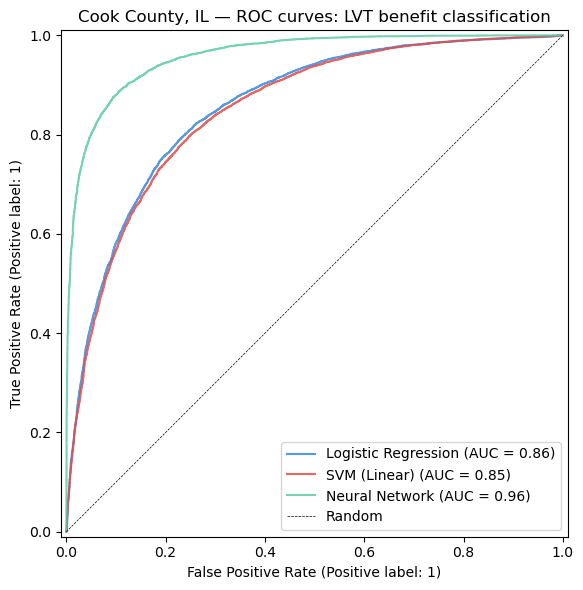

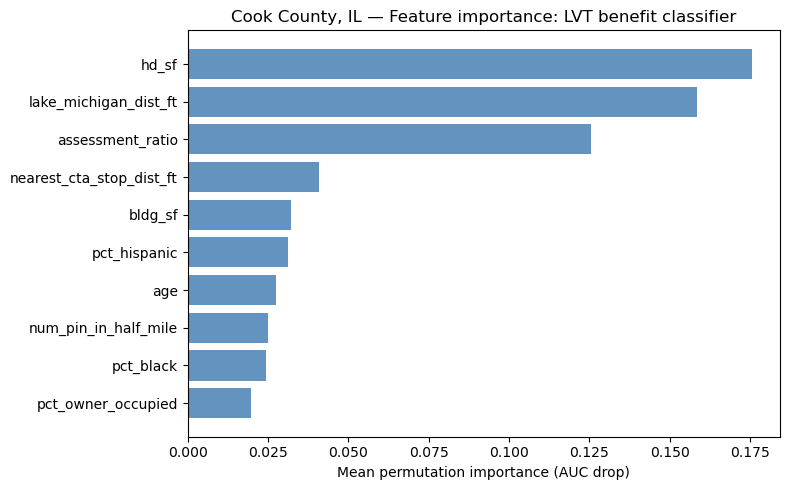

In [12]:
plot_roc_curves(
    clf_models, X_test_scaled, y_test_c,
    city_label=LABEL, save_path=FIGURES_DIR / f'{CITY}_classification_roc.png',
)
plt.show()

plot_permutation_importance(
    clf_models, X_test_scaled, y_test_c, clf_features,
    city_label=LABEL, save_path=FIGURES_DIR / f'{CITY}_classification_importance.png',
)
plt.show()


In [13]:
best_r2 = val_results.loc[val_results['R²'].idxmax(), 'R²']
best_mdape = val_results.loc[val_results['R²'].idxmax(), 'MdAPE (%)']
gap = (tract_stats[tract_stats['majority_black'] == 1]['median_ratio'].median() -
       tract_stats[tract_stats['majority_white'] == 1]['median_ratio'].median())
pct_ben = res_lvt['lvt_benefits'].mean() * 100
best_auc = clf_results['AUC'].max()

print(f'\n{LABEL}')
print(f'  AVM: {best_model_name} R²={best_r2:.3f}, MdAPE={best_mdape:.1f}%')
print(f'  Equity: Black/White ratio gap = {gap:+.3f}')
print(f'  LVT: {pct_ben:.1f}% of parcels pay less ({best_k} clusters)')
print(f'  Classifier AUC = {best_auc:.3f}')



Cook County, IL
  AVM: LightGBM R²=0.817, MdAPE=15.2%
  Equity: Black/White ratio gap = -0.186
  LVT: 61.3% of parcels pay less (8 clusters)
  Classifier AUC = 0.959
